In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,465 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 124947 files and dire

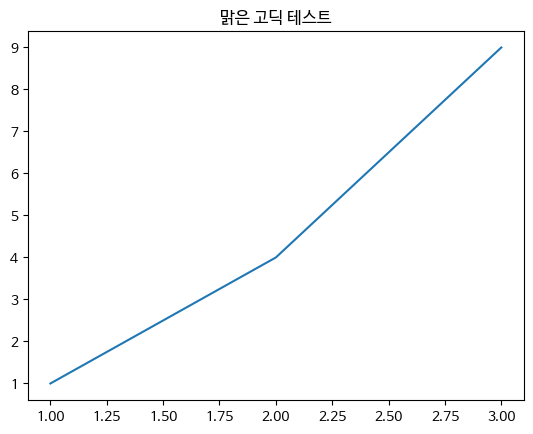

In [1]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')
plt.plot([1, 2, 3], [1, 4, 9])
plt.title('맑은 고딕 테스트')
plt.show()

In [2]:
# 드라이브에서 파일 가져오기
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np

# 파일 경로
img_file_path = '/content/drive/My Drive/apple_images.npy'
label_file_path = '/content/drive/My Drive/apple_labels.npy'

# 파일 로드
img_data = np.load(img_file_path)
label_data = np.load(label_file_path)

print(img_data.shape)
print(label_data.shape)

(1564, 224, 224, 3)
(1564,)


In [4]:
# 0: 특, 1: 상, 2: 보통
from typing import Counter
count = Counter(label_data)
print(count)

Counter({2: 522, 0: 521, 1: 521})


In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

# 이미지 데이터 정규화 및 타입 변환
img_data = np.array(img_data, dtype=np.float32) / 255.0
label_data = np.array(label_data, dtype=int)

# 데이터 나누기
x_train, x_test, y_train, y_test = train_test_split(img_data, label_data, test_size=0.1, stratify=label_data, random_state=42)

# One-Hot Encoding
y_train_categorical = to_categorical(y_train, num_classes=3)
y_test_categorical = to_categorical(y_test, num_classes=3)

# CNN 모델 설계
# 다음은 모델에 필요한 모듈을 불러온 후, 모델 층을 쌓는 코드 입니다.
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Sequential

model = Sequential([
    # 입력: 224x224x3
    Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),  # 112x112x16

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),  # 56x56x32

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),  # 28x28x64

    # 이 시점에서 특성 맵 크기 크게 감소
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    GlobalAveragePooling2D(),  # 파라미터 수 크게 감소

    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,691 (244.89 KB)

 Trainable params: 62,691 (244.89 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import Recall, Precision, AUC

optimizer = Adam(learning_rate=0.001)

# 다중 클래스 분류를 위한 컴파일 설정
model.compile(
   optimizer=optimizer,
   loss='categorical_crossentropy',  # 손실함수
   metrics=['accuracy', 'AUC', 'Precision', 'Recall']
)

# ModelCheckpoint 콜백 설정
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1)

In [7]:
# 모델 학습
base_history = model.fit(x_train, y_train_categorical, batch_size=32, validation_split=0.2, epochs=20, callbacks=[model_checkpoint])

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 226ms/step - AUC: 0.4890 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.3123 - loss: 1.1017 - val_AUC: 0.4759 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.2979 - val_loss: 1.1021
Epoch 2/20
 5/36 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - AUC: 0.5609 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.3400 - loss: 1.0914

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_auc available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - AUC: 0.5292 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.3415 - loss: 1.0957 - val_AUC: 0.4905 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.3191 - val_loss: 1.0990
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - AUC: 0.5020 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.3496 - loss: 1.0985 - val_AUC: 0.4912 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.3191 - val_loss: 1.1039
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - AUC: 0.5008 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - accuracy: 0.3330 - loss: 1.0992 - val_AUC: 0.5391 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.3050 - val_loss: 1.0962
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - AUC: 0.5657 - Precision: 0.1489 - Recall: 0.0014 - accuracy: 0.3988 - loss: 1.0908 - val_AUC: 0.5932 - val_Precision: 0.7727 - val_Recall: 0.0603 - val_accuracy: 0.3475 - val_loss: 1.0523

In [8]:
# 모델 평가 (여러 지표가 반환되는 경우)
eval_results = model.evaluate(x_test, y_test_categorical)

# 각 평가 지표 출력
print(f"Test Loss: {eval_results[0]}")
print(f"Test Accuracy: {eval_results[1]}")
print(f"AUC: {eval_results[2]}")
print(f"Precision: {eval_results[3]}")
print(f"Recall: {eval_results[4]}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - AUC: 0.9188 - Precision: 0.7929 - Recall: 0.6657 - accuracy: 0.7100 - loss: 0.5188
Test Loss: 0.5339199304580688
Test Accuracy: 0.7197452187538147
AUC: 0.9120349884033203
Precision: 0.770370364189148
Recall: 0.662420392036438


In [9]:
from sklearn.metrics import accuracy_score

# 모델 예측
y_pred = model.predict(x_test)
y_pred_arg = np.argmax(y_pred, axis=1)

y_pred_arg

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step


array([1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 2, 2, 1, 2, 0,
       0, 0, 1, 2, 0, 2, 1, 2, 1, 1, 0, 1, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0,
       2, 0, 0, 2, 0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 2, 0, 0, 1, 1, 0, 0, 1, 2,
       1, 1, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 2, 1, 0, 0, 0, 0, 2, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 1, 2,
       0, 2, 1])

In [ ]:
model.save('/content/drive/MyDrive/apple_dl_model_v1.keras')